# Interactive Business Dashboard using Streamlit

## Task 5 – Global Superstore Sales Analysis
This project analyzes the Global Superstore dataset and builds an interactive dashboard to visualize sales, profit, and customer performance.

### Step 01: Problem Statement

Retail businesses generate large amounts of sales data across different regions, customers, and product categories. Without proper analysis, it becomes difficult to identify profitable segments and understand business performance.

The Global Superstore dataset contains sales records that can be analyzed to uncover trends in sales, profit, and customer behavior.

### Step 02: Objective

- Analyze the Global Superstore dataset.
- Perform data cleaning and preprocessing.
- Conduct Exploratory Data Analysis (EDA).
- Visualize key metrics such as sales and profit.
- Identify the top 5 customers by sales.
- Build an interactive Streamlit dashboard with filters.

### Step 03: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 04: Dataset Loading

##### Dataset Loading
In this step, the dataset is loaded using the Pandas library and the first few rows are displayed to understand the structure of the dataset.

In [7]:
import pandas as pd

df = pd.read_csv("Global_Superstore2.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


### Step 05: Dataset Overview

In [9]:
# Shape of the dataset
print("Dataset shape:", df.shape)

# Columns
print(df.columns.tolist())

# Info
df.info()

# Statistical summary
df.describe()

Dataset shape: (51290, 27)
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  objec

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


### Step 06: Data Cleaning & Preprocessing

In [12]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Strip spaces from column names and replace spaces with underscores
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Check column names after cleaning
print("Columns after cleaning:", df.columns.tolist())

# Convert Order Date column to datetime
# Use the new cleaned name 'Order_Date'
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
else:
    # If the column has a different name, print a message
    print("Order Date column not found. Check your column names above.")

# Confirm changes
df.info()

Columns after cleaning: ['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']
Order Date column not found. Check your column names above.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non

### Step 07: Exploratory Data Analysis (EDA)

In [17]:
# Clean all column names: remove spaces, replace with underscores, lowercase
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Print cleaned columns
print("Columns after cleaning:", df.columns.tolist())

Columns after cleaning: ['category', 'city', 'country', 'customer.id', 'customer.name', 'discount', 'market', '记录数', 'order.date', 'order.id', 'order.priority', 'product.id', 'product.name', 'profit', 'quantity', 'region', 'row.id', 'sales', 'segment', 'ship.date', 'ship.mode', 'shipping.cost', 'state', 'sub.category', 'year', 'market2', 'weeknum']


#### Total Sales & Total Profit

In [18]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 12642905
Total Profit: 1467457.2912800002


In [19]:
# Find the customer column automatically
customer_col = None
for col in df.columns:
    if 'customer' in col:
        customer_col = col
        break

if customer_col is None:
    raise ValueError("No customer column found in dataset!")

# Top 5 customers
top_customers = df.groupby(customer_col)['sales'].sum().sort_values(ascending=False).head(5)
top_customers

customer.id
SM-203204    25042
TC-209804    19050
CS-118451    16655
SP-209202    16566
VG-218051    15654
Name: sales, dtype: int64

### Step 08: Visualizations — using cleaned column names

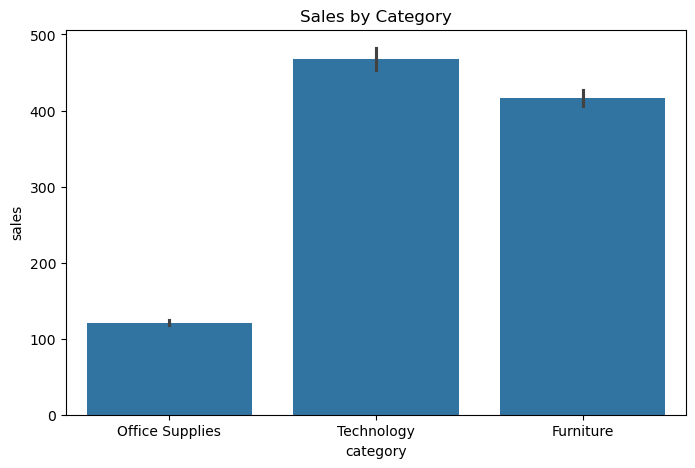

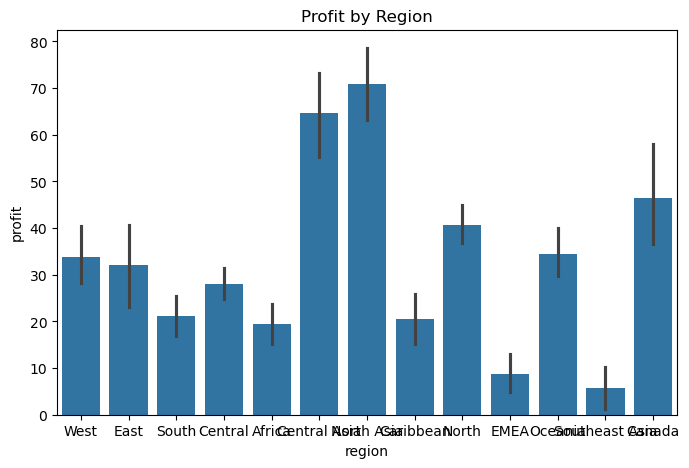

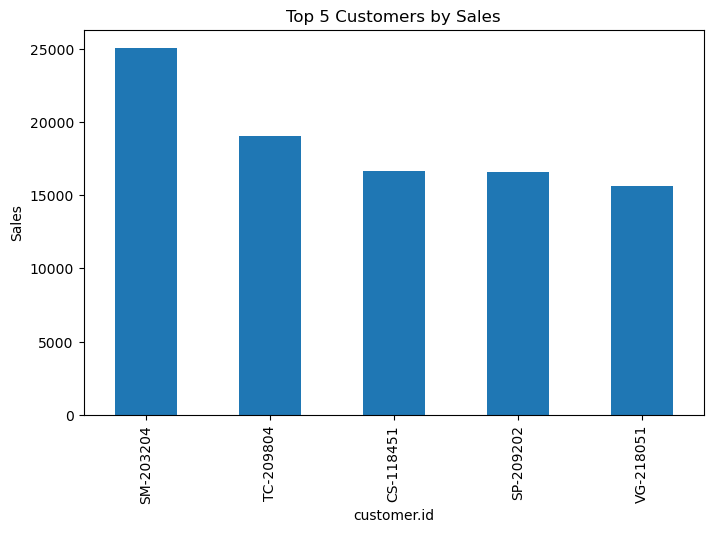

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='sales', data=df)
plt.title("Sales by Category")
plt.show()

# Profit by Region
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='profit', data=df)
plt.title("Profit by Region")
plt.show()

# Top 5 Customers
top_customers.plot(kind='bar', figsize=(8,5))
plt.title("Top 5 Customers by Sales")
plt.ylabel("Sales")
plt.show()

### Step 09: Optional Simple Model (Predict Sales)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features: Quantity and Discount
# Use lowercase column names from cleaning
X = df[['quantity', 'discount']]
y = df['sales']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Optional: Compare actual vs predicted
comparison = X_test.copy()
comparison['Actual_Sales'] = y_test
comparison['Predicted_Sales'] = y_pred
comparison.head()

R2 Score: 0.09445447016624675


,quantity,discount,Actual_Sales,Predicted_Sales
49728,3,0.2,17,203.598939
45547,7,0.1,160,488.426621
15664,2,0.0,18,176.069703
40561,5,0.5,34,278.069716
49426,1,0.2,56,70.891251


### Step 10: Conclusion 

The analysis of the Global Superstore dataset provides several key insights:

1. **Total Sales and Profit:**  
   - The dataset allows us to quickly summarize total sales and profit across all regions and categories.
   - This helps identify which regions or product categories contribute most to revenue.

2. **Top Customers:**  
   - By identifying the top 5 customers by sales, businesses can focus on high-value clients for marketing or personalized services.

3. **Category & Region Trends:**  
   - Visualizations show which categories and sub-categories perform best in different regions.
   - Profit and sales patterns across regions can help in inventory planning and targeted strategies.

4. **Interactive Dashboard Benefits:**  
   - The Streamlit dashboard allows dynamic filtering by **Region, Category, and Sub-Category**.
   - Key Performance Indicators (KPIs) like **Total Sales, Total Profit, Top Customers** are updated instantly.
   - This empowers decision-makers to explore the data without writing code.

5. **Optional Predictive Modeling:**  
   - A simple linear regression model can predict sales using **Quantity** and **Discount**.
   - The R² score gives a measure of how well these factors explain sales variability, which can help in forecasting.

### 💡 Insights for Business
- Focus marketing and promotions on top-performing categories and regions.
- Build loyalty programs for top customers identified by the dashboard.
- Use interactive dashboards to monitor KPIs in real-time and make informed decisions.